# [LAB 06] . 데이터 분포 시각화
### 패키지 참조

In [1]:
from hossam import load_data
from matplotlib import font_manager as fm
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [3]:
origin = load_data("traffic_acc")
origin

[data] https://data.hossam.kr/data/lab04/traffic_acc.xlsx
[desc] 2005년 1월 부터 2018년 12월 까지 월별 교통사고의 발생건수,부상자수,사망자수 데이터(인덱스/메타데이터 없음, 출처: 공공데이터포털)
[!] Cannot read metadata


,년도,월,발생건수,사망자수,부상자수
0,2005,1,15494,504,25413
1,2005,2,13244,431,21635
2,2005,3,16580,477,25550
3,2005,4,17817,507,28131
4,2005,5,19085,571,29808
...,...,...,...,...,...
163,2018,8,18335,357,27749
164,2018,9,18371,348,27751
165,2018,10,19738,373,28836
166,2018,11,19029,298,28000


In [8]:
df = origin.drop('월',axis=1).groupby('년도').mean()
df

,발생건수,사망자수,부상자수
년도,,,
2005,17847.583333,531.333333,28519.416667
2006,17812.083333,527.250000,28352.416667
2007,17638.500000,513.833333,27992.166667
2008,17985.166667,489.166667,28246.833333
2009,19332.500000,486.500000,30156.250000
2010,18906.500000,458.750000,29371.500000
2011,18475.916667,435.750000,28449.250000
2012,18638.000000,449.333333,28713.750000
2013,17946.166667,424.333333,27392.583333


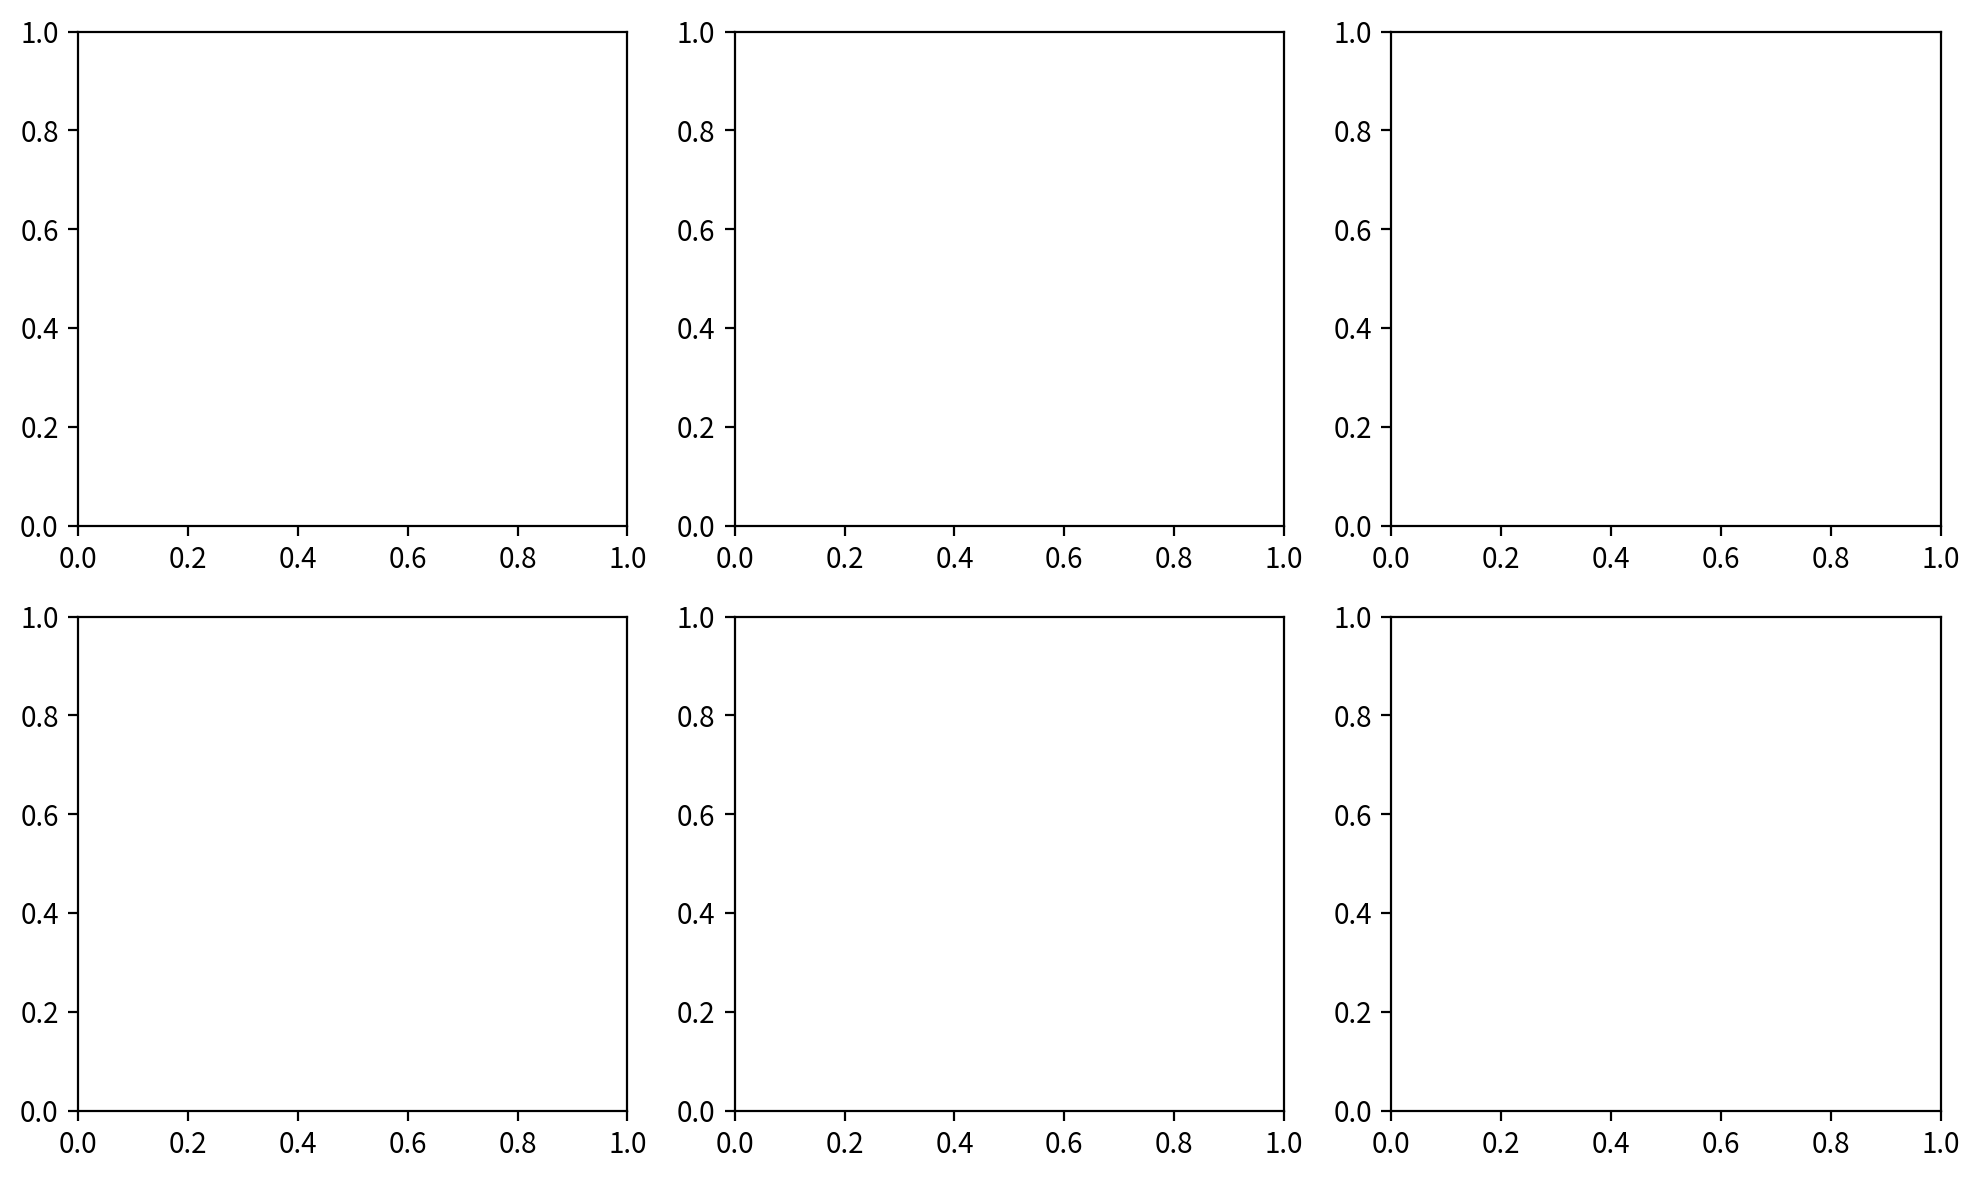

In [ ]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 2000
height_px = 1200
rows = 2
cols = 3
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)


# 3) 그래프 꾸미기
# 전체 제목
fig.suptitle('서브플롯 영역 나누기', fontsize=14, color='#006600')

# 각 그래프 간의 가로(wspace),세로(hspace) 간격 지정
fig.subplots_adjust(wspace=0.2, hspace=0.2)


plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

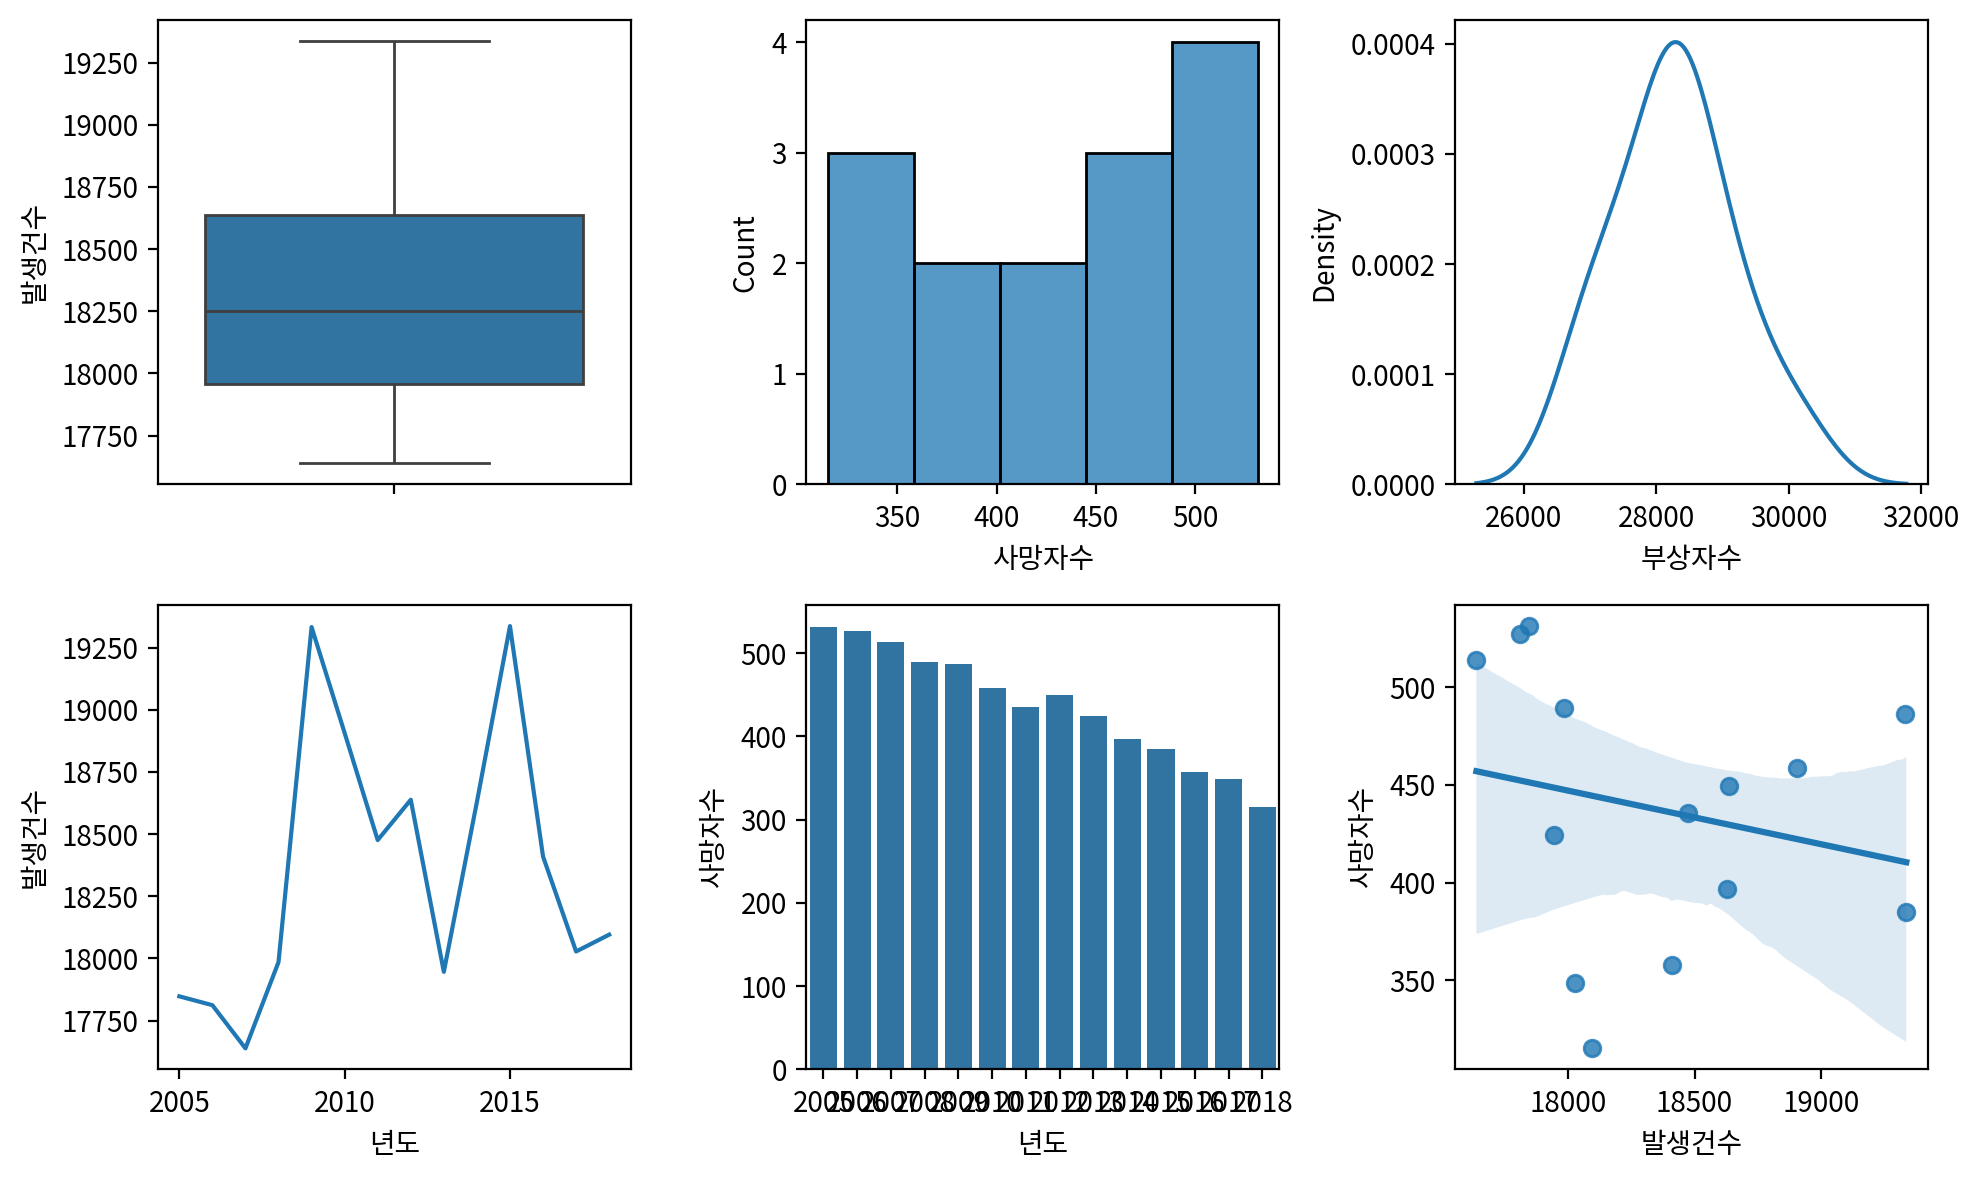

In [9]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 2000
height_px = 1200
rows = 2
cols = 3
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)


# 2) 그래프 그리기
sb.boxplot(data=df, y='발생건수', ax=ax[0][0])
sb.histplot(data=df, x='사망자수', bins=5, ax=ax[0][1])
sb.kdeplot(data=df, x='부상자수', ax=ax[0][2])
sb.lineplot(data=df, x=df.index, y='발생건수', ax=ax[1][0])
sb.barplot(data=df, x=df.index, y='사망자수', estimator=np.sum,ax=ax[1][1])
sb.regplot(data=df, x='발생건수', y='사망자수', ax=ax[1][2])


# 각 그래프 간의 가로(wspace),세로(hspace) 간격 지정
fig.subplots_adjust(wspace=0.2, hspace=0.2)


plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

In [10]:
x = np.arange(10)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [12]:
y1 = np.arange(10)
y1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
y2 = x**2
y2

array([ 0,  1,  4,  9, 16, 25, 36, 49, 64, 81])

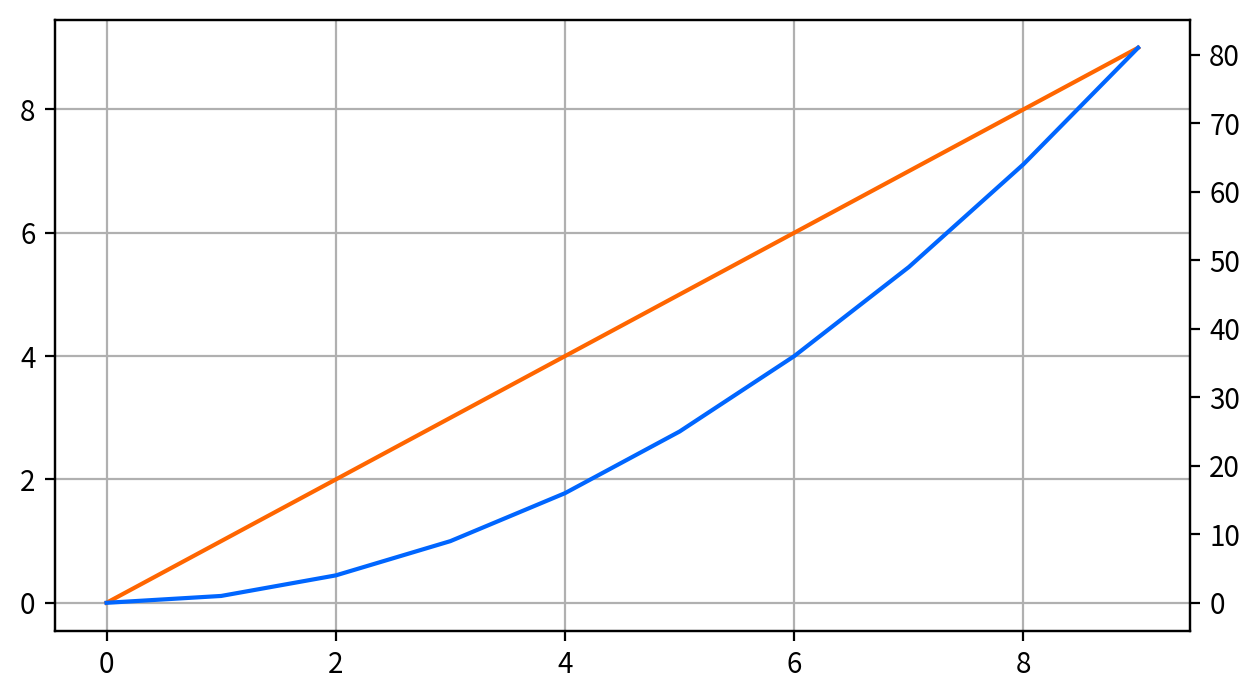

In [14]:
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax1 = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# ax1에 겹쳐지는 쌍둥이 서브플롯을 생성
ax2 = ax1.twinx()
# 2) LinePlot 그리기
sb.lineplot(x=x, y=y1, color='#ff6600', ax=ax1)
sb.lineplot(x=x, y=y2, color='#0066ff', ax=ax2)
# 3) 그래프 꾸미기
ax1.grid(True) # 그래프가 겹쳐지므로 격자는 하나만 표시해도 됨
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

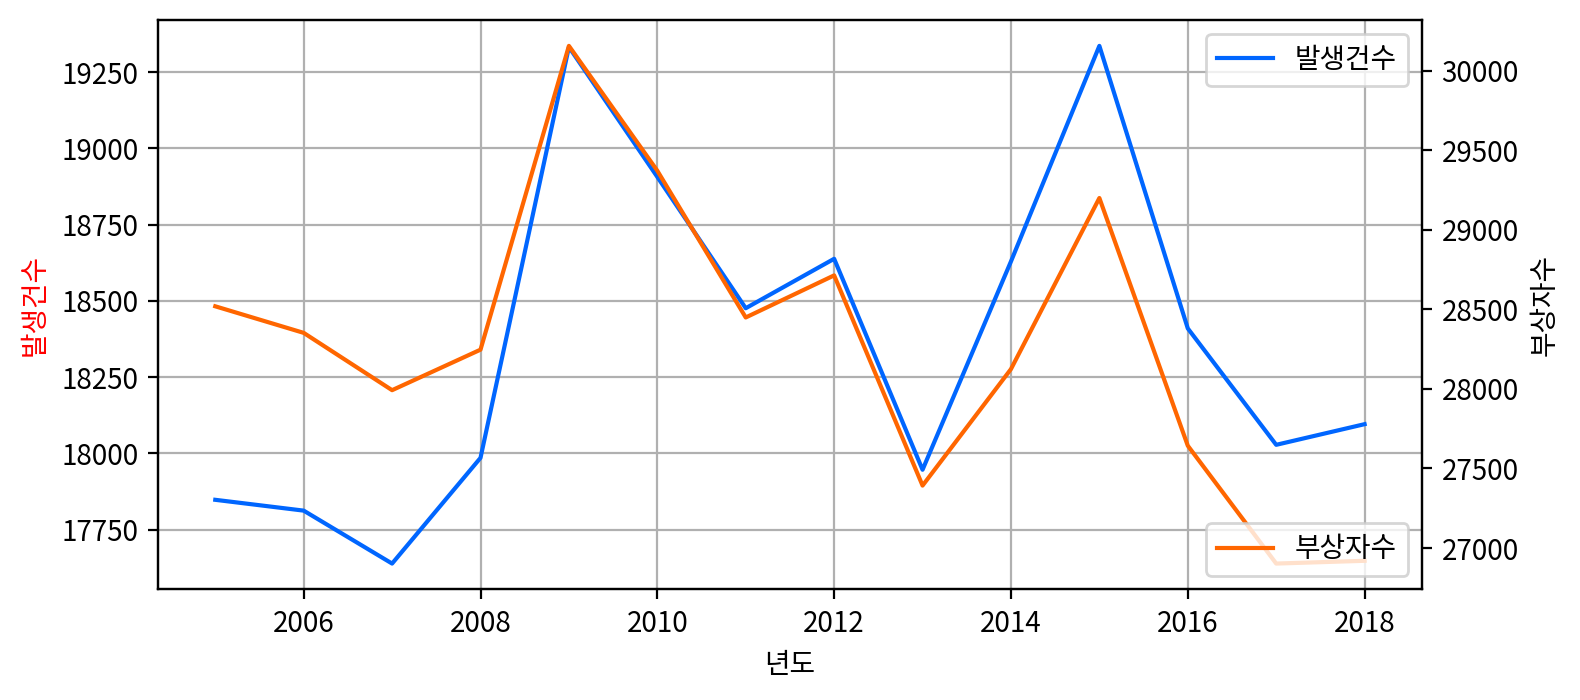

In [19]:
# 1) 그래프 초기화
width_px = 1600 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax1 = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# ax1에 겹쳐지는 쌍둥이 서브플롯을 생성
ax2 = ax1.twinx()
# 2) LinePlot 그리기
sb.lineplot(data=df, x=df.index, y='발생건수' ,ax=ax1, label='발생건수', color='#0066ff',)
sb.lineplot(data=df, x=df.index, y='부상자수', ax=ax2, label='부상자수',color='#ff6600')


# 3) 그래프 꾸미기
ax1.set_xlabel('년도')
ax1.set_ylabel('발생건수', color='#ff0000')
ax1.grid(True) # 그래프가 겹쳐지므로 격자는 하나만 표시해도 됨
ax1.legend(loc='upper right')
ax2.legend(loc='lower right')
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료